# Mini-BLIP2 Test Notebook

这个 notebook 用来加载 `train.ipynb` 训练好的 checkpoint，并对图片生成英文 caption。请先运行训练 notebook，确保 `code/outputs/mini_blip2_flickr8k.pt` 已经存在。

In [9]:
import csv
import random
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from PIL import Image
from tqdm.auto import tqdm
from transformers import AutoTokenizer, CLIPImageProcessor, CLIPVisionModel, OPTForCausalLM

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cuda


In [10]:
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'code':
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / 'data'
IMAGE_DIR_CANDIDATES = [DATA_DIR / 'Images', DATA_DIR]
IMAGE_DIR = next((path for path in IMAGE_DIR_CANDIDATES if path.exists() and any(path.glob('*.jpg'))), DATA_DIR / 'Images')
CAPTION_FILE = DATA_DIR / 'captions.txt'
OUTPUT_DIR = PROJECT_ROOT / 'code' / 'outputs'
CHECKPOINT_PATH = OUTPUT_DIR / 'mini_blip2_flickr8k.pt'

DEFAULT_CONFIG = {
    'num_query_tokens': 16,
    'qformer_dim': 256,
    'qformer_layers': 2,
    'qformer_heads': 8,
    'vision_model': 'openai/clip-vit-base-patch32',
    'language_model': 'facebook/opt-125m',
    'caption_prompt': 'A photo of',
}

assert CHECKPOINT_PATH.exists(), f'没有找到 checkpoint: {CHECKPOINT_PATH}。请先运行 train.ipynb 完成训练。'
checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
CONFIG = DEFAULT_CONFIG.copy()
CONFIG.update(checkpoint.get('config', {}))
CONFIG['caption_prompt'] = CONFIG.get('caption_prompt') or 'A photo of'

print('Project root:', PROJECT_ROOT)
print('Image dir:', IMAGE_DIR)
print('Checkpoint:', CHECKPOINT_PATH)
print('Prompt:', CONFIG['caption_prompt'])

Project root: E:\program_prject\vscode_python_project\论文复现\blip2-main\blip2-main
Image dir: E:\program_prject\vscode_python_project\论文复现\blip2-main\blip2-main\data\Images
Checkpoint: E:\program_prject\vscode_python_project\论文复现\blip2-main\blip2-main\code\outputs\mini_blip2_flickr8k.pt
Prompt: A photo of


## 1. 读取 caption 标注和测试图片

如果想测试指定图片，把图片路径填到 `TEST_IMAGE_PATHS`。如果保持空列表，notebook 会从 `data/Images` 中随机抽取图片。

In [11]:
def load_captions(caption_file):
    captions_by_image = defaultdict(list)
    if not caption_file.exists():
        return captions_by_image
    with open(caption_file, 'r', encoding='utf-8') as f:
        reader = csv.DictReader(f)
        for row in reader:
            image_name = row['image'].strip()
            caption = row['caption'].strip()
            if image_name and caption:
                captions_by_image[image_name].append(caption)
    return captions_by_image


captions_by_image = load_captions(CAPTION_FILE)
all_images = sorted([
    path for path in IMAGE_DIR.iterdir()
    if path.suffix.lower() in {'.jpg', '.jpeg', '.png'}
])
print('Images found:', len(all_images))
print('Images with captions:', len(captions_by_image))

Images found: 8091
Images with captions: 8091


In [12]:
TEST_IMAGE_PATHS = [
    # 示例：r'E:\\path\\to\\your\\image.jpg'
]
NUM_RANDOM_EXAMPLES = 5

if TEST_IMAGE_PATHS:
    test_images = [Path(path) for path in TEST_IMAGE_PATHS]
else:
    random.seed(42)
    test_images = random.sample(all_images, k=min(NUM_RANDOM_EXAMPLES, len(all_images)))

for path in test_images:
    print(path.name)

3354489242_dd529ffa1f.jpg
2071309418_1d7580b0f0.jpg
1247181182_35cabd76f3.jpg
3523950181_414978964e.jpg
2554570943_122da6438f.jpg


## 2. 定义模型结构

测试时的模型结构必须和训练时一致，然后加载 checkpoint 中训练好的 Mini Q-Former 和投影层参数。

In [13]:
class MiniQFormer(nn.Module):
    def __init__(self, num_query_tokens=16, qformer_dim=256, num_layers=2, num_heads=8, vision_dim=768):
        super().__init__()
        self.query_tokens = nn.Parameter(torch.randn(1, num_query_tokens, qformer_dim) * 0.02)
        self.vision_to_q = nn.Linear(vision_dim, qformer_dim)
        self.layers = nn.ModuleList([
            nn.TransformerDecoderLayer(
                d_model=qformer_dim,
                nhead=num_heads,
                dim_feedforward=qformer_dim * 4,
                dropout=0.1,
                batch_first=True,
                norm_first=True,
            )
            for _ in range(num_layers)
        ])
        self.norm = nn.LayerNorm(qformer_dim)

    def forward(self, image_features):
        memory = self.vision_to_q(image_features)
        queries = self.query_tokens.expand(image_features.size(0), -1, -1)
        for layer in self.layers:
            queries = layer(tgt=queries, memory=memory)
        return self.norm(queries)


class MiniBLIP2(nn.Module):
    def __init__(self, config, tokenizer):
        super().__init__()
        self.tokenizer = tokenizer
        self.vision_encoder = CLIPVisionModel.from_pretrained(config['vision_model'])
        self.language_model = OPTForCausalLM.from_pretrained(config['language_model'])

        vision_dim = self.vision_encoder.config.hidden_size
        lm_dim = self.language_model.config.hidden_size
        self.qformer = MiniQFormer(
            num_query_tokens=config['num_query_tokens'],
            qformer_dim=config['qformer_dim'],
            num_layers=config['qformer_layers'],
            num_heads=config['qformer_heads'],
            vision_dim=vision_dim,
        )
        self.q_to_lm = nn.Linear(config['qformer_dim'], lm_dim)

        for param in self.vision_encoder.parameters():
            param.requires_grad = False
        for param in self.language_model.parameters():
            param.requires_grad = False

    def encode_image_prefix(self, pixel_values):
        with torch.no_grad():
            vision_outputs = self.vision_encoder(pixel_values=pixel_values)
            image_features = vision_outputs.last_hidden_state
        q_outputs = self.qformer(image_features)
        return self.q_to_lm(q_outputs)

    @torch.no_grad()
    def generate_caption(self, pixel_values, prompt='A photo of', max_new_tokens=30, min_new_tokens=5, num_beams=3):
        self.eval()
        prefix_embeds = self.encode_image_prefix(pixel_values)
        prompt_inputs = self.tokenizer(prompt, return_tensors='pt', add_special_tokens=False).to(pixel_values.device)
        prompt_embeds = self.language_model.get_input_embeddings()(prompt_inputs['input_ids'])
        prompt_embeds = prompt_embeds.expand(prefix_embeds.size(0), -1, -1)
        inputs_embeds = torch.cat([prefix_embeds, prompt_embeds], dim=1)
        attention_mask = torch.ones(inputs_embeds.shape[:2], dtype=torch.long, device=pixel_values.device)

        generated_ids = self.language_model.generate(
            inputs_embeds=inputs_embeds,
            attention_mask=attention_mask,
            max_new_tokens=max_new_tokens,
            min_new_tokens=min_new_tokens,
            num_beams=num_beams,
            do_sample=False,
            repetition_penalty=1.2,
            no_repeat_ngram_size=2,
            pad_token_id=self.tokenizer.pad_token_id,
            eos_token_id=self.tokenizer.eos_token_id,
        )
        captions = []
        clean_texts = self.tokenizer.batch_decode(generated_ids, skip_special_tokens=True)
        raw_texts = self.tokenizer.batch_decode(generated_ids, skip_special_tokens=False)
        for clean_text, raw_text in zip(clean_texts, raw_texts):
            text = clean_text.strip()
            if text.lower().startswith(prompt.lower()):
                text = text[len(prompt):].strip()
            if not text:
                print('Raw generated tokens:', raw_text)
                text = f'{prompt} something.'
            captions.append(text)
        return captions

## 3. 加载 checkpoint

In [14]:
image_processor = CLIPImageProcessor.from_pretrained(CONFIG['vision_model'])
tokenizer = AutoTokenizer.from_pretrained(CONFIG['language_model'])
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = MiniBLIP2(CONFIG, tokenizer).to(device)
missing, unexpected = model.load_state_dict(checkpoint['model_state_dict'], strict=False)
model.eval()

print('Missing keys:', missing)
print('Unexpected keys:', unexpected)
print('Model loaded.')

Missing keys: []
Unexpected keys: []
Model loaded.


## 4. 生成 caption 并展示结果

In [15]:
@torch.no_grad()
def caption_one_image(image_path):
    image = Image.open(image_path).convert('RGB')
    pixel_values = image_processor(images=image, return_tensors='pt')['pixel_values'].to(device)
    caption = model.generate_caption(
        pixel_values,
        prompt=CONFIG['caption_prompt'],
        max_new_tokens=30,
        min_new_tokens=5,
        num_beams=3,
    )[0]
    return caption.strip()


results = []
for image_path in tqdm(test_images, desc='generate'):
    pred = caption_one_image(image_path)
    gt_list = captions_by_image.get(image_path.name, [])
    gt = gt_list[0] if gt_list else ''
    results.append({'image_path': image_path, 'image_name': image_path.name, 'gt': gt, 'pred': pred})
    print('\nImage:', image_path.name)
    print('GT  :', gt if gt else '(no caption in captions.txt)')
    print('Pred:', pred if pred else '(empty)')

generate:   0%|          | 0/5 [00:00<?, ?it/s]


Image: 3354489242_dd529ffa1f.jpg
GT  : A goalie tries to block the puck in a hockey game .
Pred: A hockey player in a red jersey stands in front of a goal. The player is wearing a blue jersey.
The players are standing in the

Image: 2071309418_1d7580b0f0.jpg
GT  : A white dog wearing a christmas reindeer headband plays with a brown dog in the grass among some stuffed animals .
Pred: A brown dog and a black dog are playing in a grassy area.
The dog is playing with a toy toy. The dog has a

Image: 1247181182_35cabd76f3.jpg
GT  : a man sits on a rock .
Pred: A man is climbing a mountain.
The man in the picture is wearing a white shirt and blue jeans. He is standing on a rock.

Image: 3523950181_414978964e.jpg
GT  : A goalie is covering his net while two other hockey players chase after the hockey puck .
Pred: A hockey player in a red jersey stands in front of a goal.
Two hockey players in red jerseys stand in the middle of the ice.

Image: 2554570943_122da6438f.jpg
GT  : A child climbs u

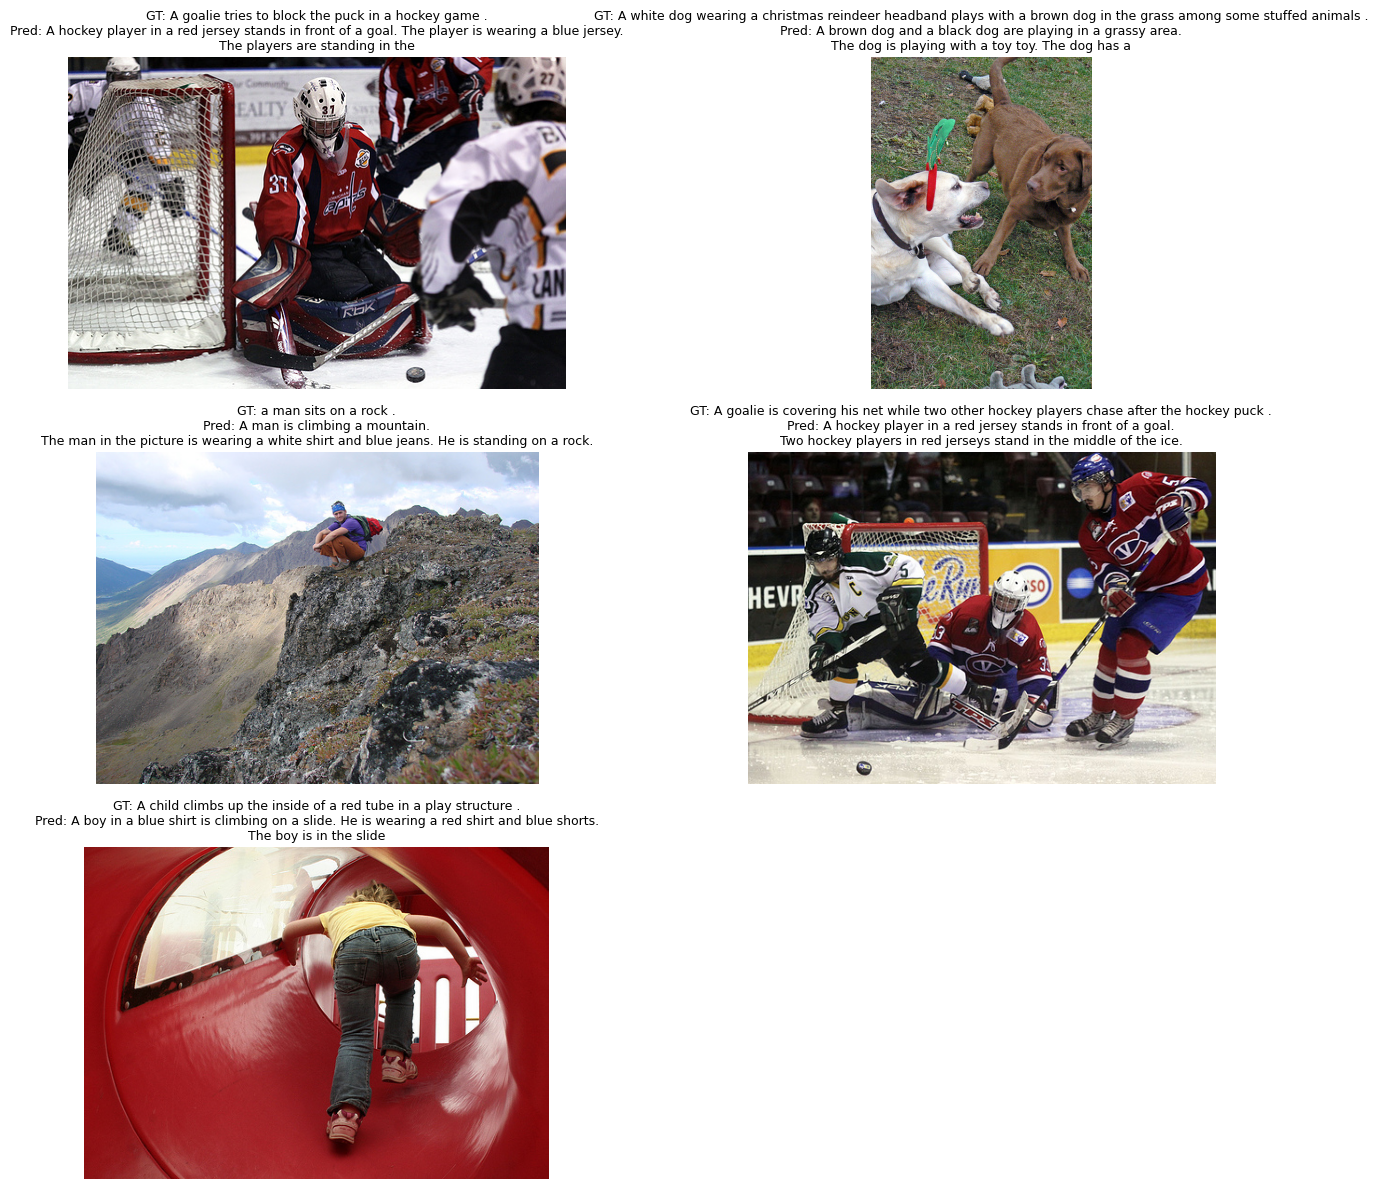

Saved result image to: E:\program_prject\vscode_python_project\论文复现\blip2-main\blip2-main\code\outputs\test_generation_examples.png


In [16]:
cols = 2
rows = max(1, (len(results) + cols - 1) // cols)
plt.figure(figsize=(14, 4 * rows))

for i, item in enumerate(results):
    image = Image.open(item['image_path']).convert('RGB')
    plt.subplot(rows, cols, i + 1)
    plt.imshow(image)
    plt.axis('off')
    gt = item['gt'] if item['gt'] else 'no ground truth'
    pred = item['pred'] if item['pred'] else 'empty output'
    plt.title(f"GT: {gt}\nPred: {pred}", fontsize=9)

plt.tight_layout()
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
save_path = OUTPUT_DIR / 'test_generation_examples.png'
plt.savefig(save_path, dpi=160)
plt.show()
print('Saved result image to:', save_path)